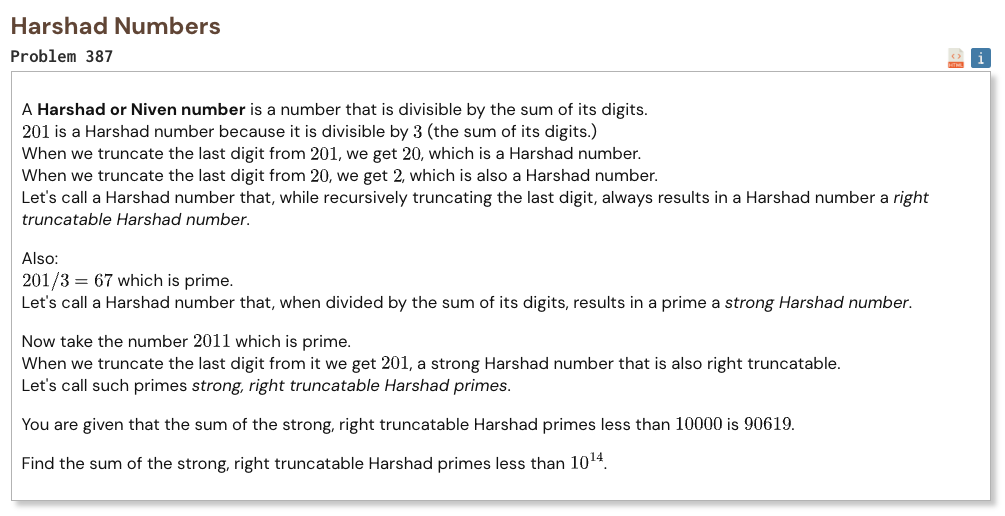

## Initial approach

* start with the one digit numbers because every nonzero digit is a Harshad number
* append digits from 0 to 9 to build longer numbers
* keep a new number only when it is divisible by its digit sum
* this automatically generates only right truncatable Harshad numbers
* check whether dividing a Harshad number by its digit sum gives a prime
* when it is strong append 1 3 7 or 9 and test whether the resulting number is prime
* add every valid prime below the limit
* use Miller Rabin primality testing

In [1]:
def is_prime(number):
    if number < 2:
        return False

    small_primes = (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37)

    for prime in small_primes:
        if number % prime == 0:
            return number == prime

    exponent = number - 1
    power_of_two = 0

    while exponent % 2 == 0:
        exponent //= 2
        power_of_two += 1

    for base in (2, 3, 5, 7, 11, 13, 17):
        if base >= number:
            continue

        value = pow(base, exponent, number)

        if value == 1 or value == number - 1:
            continue

        for _ in range(power_of_two - 1):
            value = value * value % number

            if value == number - 1:
                break
        else:
            return False

    return True


def solve(limit):
    result = 0
    current = [(digit, digit) for digit in range(1, 10)]

    while current:
        next_numbers = []

        for number, digit_sum in current:
            quotient = number // digit_sum

            if is_prime(quotient):
                for final_digit in (1, 3, 7, 9):
                    candidate = number * 10 + final_digit

                    if candidate < limit and is_prime(candidate):
                        result += candidate

            for digit in range(10):
                candidate = number * 10 + digit

                if candidate >= limit // 10:
                    continue

                new_digit_sum = digit_sum + digit

                if candidate % new_digit_sum == 0:
                    next_numbers.append((candidate, new_digit_sum))

        current = next_numbers

    return result


assert solve(10_000) == 90_619

In [2]:
%%time
result = solve(10**14)
print("Result:", result)

Result: 696067597313468
CPU times: user 30.5 ms, sys: 1.5 ms, total: 32 ms
Wall time: 31.5 ms
